# Modality-Level Shapley Values by Reaction Time

**Purpose**: Compute Shapley values for each modality (Behavior, Physio, Gaze, EEG) separately for Fast vs Slow reaction time groups.

**Key Question**: Does the relative contribution of physiological/neural signals differ between fast (more automatic) vs slow (more deliberative) decisions?

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from itertools import combinations
from math import factorial
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

OUTPUT_DIR = Path('../../data/results/main/shapley_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("MODALITY SHAPLEY VALUES BY REACTION TIME")
print("="*70)

MODALITY SHAPLEY VALUES BY REACTION TIME


## 1. Load Data

In [2]:
# Load features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Load EEG features
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

# Merge EEG with main dataframe
merged_df = merged_df.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"Total trials: {len(merged_df)}")
print(f"Subjects: {merged_df['subject_id'].nunique()}")
print(f"\nFeature counts:")
print(f"  Behavior: {len(behavior_cols)}")
print(f"  Physio: {len(physio_cols)}")
print(f"  Gaze: {len(gaze_cols)}")
print(f"  EEG: {len(eeg_cols)}")

Total trials: 9365
Subjects: 80

Feature counts:
  Behavior: 11
  Physio: 13
  Gaze: 20
  EEG: 16


In [3]:
# Create RT groups using median split
# Use decision_time or reaction_time depending on what's available
rt_col = 'decision_time' if 'decision_time' in merged_df.columns else 'reaction_time'

median_rt = merged_df[rt_col].median()
merged_df['rt_group'] = np.where(merged_df[rt_col] <= median_rt, 'Fast', 'Slow')

print(f"\nUsing '{rt_col}' for RT split")
print(f"Median RT: {median_rt:.3f}s")
print(f"\nRT group distribution:")
print(merged_df['rt_group'].value_counts())

print(f"\nRT statistics by group:")
print(merged_df.groupby('rt_group')[rt_col].describe())


Using 'decision_time' for RT split
Median RT: 2.177s

RT group distribution:
rt_group
Fast    4683
Slow    4682
Name: count, dtype: int64

RT statistics by group:
           count      mean       std       min       25%       50%       75%  \
rt_group                                                                       
Fast      4683.0  1.661481  0.318551  0.677124  1.421450  1.688084  1.930660   
Slow      4682.0  3.003483  0.656138  2.176561  2.465503  2.844420  3.409402   

               max  
rt_group            
Fast      2.176534  
Slow      5.008581  


## 2. Define Shapley Functions

In [4]:
def evaluate_coalition(modalities_to_use, modality_data, y, subjects,
                       n_estimators=100, max_depth=5, random_state=42):
    """
    Evaluate accuracy of a coalition of modalities using LOSO CV.
    """
    if len(modalities_to_use) == 0:
        return 0.5
    
    X = np.hstack([modality_data[m] for m in modalities_to_use])
    
    logo = LeaveOneGroupOut()
    subject_accs = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        subject_accs.append(accuracy_score(y_test, y_pred))
    
    return np.mean(subject_accs)


def compute_all_coalition_values(modality_data, y, subjects, verbose=True):
    """
    Compute accuracy for all possible coalitions of modalities.
    """
    modality_names = list(modality_data.keys())
    n_modalities = len(modality_names)
    coalition_values = {}
    
    coalition_values[frozenset()] = 0.5
    
    total_coalitions = 2**n_modalities - 1
    evaluated = 0
    
    for r in range(1, n_modalities + 1):
        for combo in combinations(modality_names, r):
            coalition = frozenset(combo)
            if verbose:
                evaluated += 1
                print(f"  [{evaluated}/{total_coalitions}] {set(combo)}")
            
            acc = evaluate_coalition(list(combo), modality_data, y, subjects)
            coalition_values[coalition] = acc
            
            if verbose:
                print(f"      -> Accuracy: {acc:.4f}")
    
    return coalition_values


def compute_shapley_values(modality_data, coalition_values):
    """
    Compute Shapley values from coalition values.
    """
    modality_names = list(modality_data.keys())
    n = len(modality_names)
    shapley_values = {}
    
    for modality in modality_names:
        shapley_value = 0.0
        other_modalities = [m for m in modality_names if m != modality]
        
        for r in range(len(other_modalities) + 1):
            for combo in combinations(other_modalities, r):
                S = frozenset(combo)
                S_with_i = S | {modality}
                
                v_S = coalition_values[S]
                v_S_with_i = coalition_values[S_with_i]
                marginal = v_S_with_i - v_S
                
                s = len(S)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                
                shapley_value += weight * marginal
        
        shapley_values[modality] = shapley_value
    
    return shapley_values

## 3. Compute Shapley Values for Each RT Group

In [5]:
rt_results = {}
rt_coalitions = {}

for rt_group in ['Fast', 'Slow']:
    print(f"\n{'='*70}")
    print(f"REACTION TIME: {rt_group.upper()}")
    print(f"{'='*70}")
    
    # Filter data for this RT group
    rt_df = merged_df[merged_df['rt_group'] == rt_group].copy()
    
    print(f"Trials: {len(rt_df)}")
    print(f"Subjects: {rt_df['subject_id'].nunique()}")
    print(f"Mean RT: {rt_df[rt_col].mean():.3f}s")
    
    # Prepare feature matrices
    imputer = SimpleImputer(strategy='mean')
    
    X_behavior = imputer.fit_transform(rt_df[behavior_cols])
    X_physio = imputer.fit_transform(rt_df[physio_cols])
    X_gaze = imputer.fit_transform(rt_df[gaze_cols])
    X_eeg = imputer.fit_transform(rt_df[eeg_cols])
    
    y = rt_df['outcome'].values
    subjects = rt_df['subject_id'].values
    
    modality_data = {
        'Behavior': X_behavior,
        'Physio': X_physio,
        'Gaze': X_gaze,
        'EEG': X_eeg
    }
    
    # Compute coalition values
    print(f"\nComputing coalition values...")
    coalition_values = compute_all_coalition_values(modality_data, y, subjects, verbose=True)
    rt_coalitions[rt_group] = coalition_values
    
    # Compute Shapley values
    shapley_values = compute_shapley_values(modality_data, coalition_values)
    rt_results[rt_group] = shapley_values
    
    # Print results
    print(f"\nShapley values for {rt_group} RT:")
    total = sum(shapley_values.values())
    for mod, val in sorted(shapley_values.items(), key=lambda x: -x[1]):
        pct = 100 * val / total if total > 0 else 0
        print(f"  {mod}: {val:.4f} ({pct:.1f}%)")


REACTION TIME: FAST
Trials: 4683
Subjects: 80
Mean RT: 1.661s

Computing coalition values...
  [1/15] {'Behavior'}
      -> Accuracy: 0.7536
  [2/15] {'Physio'}
      -> Accuracy: 0.5132
  [3/15] {'Gaze'}
      -> Accuracy: 0.6294
  [4/15] {'EEG'}
      -> Accuracy: 0.5754
  [5/15] {'Physio', 'Behavior'}
      -> Accuracy: 0.7233
  [6/15] {'Gaze', 'Behavior'}
      -> Accuracy: 0.7558
  [7/15] {'EEG', 'Behavior'}
      -> Accuracy: 0.7223
  [8/15] {'Physio', 'Gaze'}
      -> Accuracy: 0.6136
  [9/15] {'EEG', 'Physio'}
      -> Accuracy: 0.5212
  [10/15] {'EEG', 'Gaze'}
      -> Accuracy: 0.6227
  [11/15] {'Physio', 'Gaze', 'Behavior'}
      -> Accuracy: 0.7372
  [12/15] {'EEG', 'Physio', 'Behavior'}
      -> Accuracy: 0.7186
  [13/15] {'EEG', 'Gaze', 'Behavior'}
      -> Accuracy: 0.7394
  [14/15] {'EEG', 'Physio', 'Gaze'}
      -> Accuracy: 0.6179
  [15/15] {'EEG', 'Physio', 'Gaze', 'Behavior'}
      -> Accuracy: 0.7388

Shapley values for Fast RT:
  Behavior: 0.1704 (71.3%)
  Gaze: 

## 4. Compare Across RT Groups

In [6]:
# Build comparison dataframe
comparison_rows = []
modality_names = ['Behavior', 'Physio', 'Gaze', 'EEG']

for rt_group in ['Fast', 'Slow']:
    shapley = rt_results[rt_group]
    total = sum(shapley.values())
    
    row = {'rt_group': rt_group}
    for mod in modality_names:
        row[f'{mod}_shapley'] = shapley[mod]
        row[f'{mod}_pct'] = 100 * shapley[mod] / total if total > 0 else 0
    
    # Add full coalition accuracy
    row['full_accuracy'] = rt_coalitions[rt_group][frozenset(modality_names)]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "="*70)
print("SHAPLEY VALUES BY REACTION TIME GROUP")
print("="*70)
print("\nRaw Shapley values (contribution to accuracy above chance):")
print(comparison_df[['rt_group'] + [f'{m}_shapley' for m in modality_names]].to_string(index=False))

print("\nNormalized Shapley values (%):")
print(comparison_df[['rt_group'] + [f'{m}_pct' for m in modality_names]].to_string(index=False))

print("\nFull model accuracy by RT group:")
print(comparison_df[['rt_group', 'full_accuracy']].to_string(index=False))


SHAPLEY VALUES BY REACTION TIME GROUP

Raw Shapley values (contribution to accuracy above chance):
rt_group  Behavior_shapley  Physio_shapley  Gaze_shapley  EEG_shapley
    Fast          0.170390       -0.007473      0.060552     0.015368
    Slow          0.101129        0.008193      0.073064     0.014319

Normalized Shapley values (%):
rt_group  Behavior_pct  Physio_pct  Gaze_pct  EEG_pct
    Fast     71.341496   -3.128695 25.352787 6.434412
    Slow     51.411592    4.165046 37.143733 7.279629

Full model accuracy by RT group:
rt_group  full_accuracy
    Fast       0.738838
    Slow       0.696706


## 5. Compare with Fusion Weights

In [7]:
# Load fusion weights for comparison
fusion_weights_path = Path('../../data/results/main/eeg_integration/fusion_models_eeg_PRE')

fusion_comparison = []
for rt in ['Fast', 'Slow']:
    try:
        w_df = pd.read_csv(fusion_weights_path / f'rt_group_eeg_PRE_{rt}_weights.csv')
        weights = dict(zip(w_df['Modality'], w_df['Weight']))
        
        # Map Physiology -> Physio
        if 'Physiology' in weights:
            weights['Physio'] = weights.pop('Physiology')
        
        shapley = rt_results[rt]
        total_shapley = sum(shapley.values())
        
        for mod in modality_names:
            fusion_comparison.append({
                'rt_group': rt,
                'modality': mod,
                'shapley_pct': 100 * shapley[mod] / total_shapley if total_shapley > 0 else 0,
                'fusion_pct': 100 * weights.get(mod, 0)
            })
    except Exception as e:
        print(f"Could not load fusion weights for {rt}: {e}")

if fusion_comparison:
    fusion_df = pd.DataFrame(fusion_comparison)
    
    print("\n" + "="*70)
    print("SHAPLEY vs FUSION WEIGHTS BY RT GROUP")
    print("="*70)
    
    for rt in ['Fast', 'Slow']:
        print(f"\n{rt} RT:")
        rt_data = fusion_df[fusion_df['rt_group'] == rt]
        print(rt_data[['modality', 'shapley_pct', 'fusion_pct']].to_string(index=False))


SHAPLEY vs FUSION WEIGHTS BY RT GROUP

Fast RT:
modality  shapley_pct  fusion_pct
Behavior    71.341496   94.371737
  Physio    -3.128695    0.938040
    Gaze    25.352787    4.513476
     EEG     6.434412    0.176747

Slow RT:
modality  shapley_pct  fusion_pct
Behavior    51.411592   46.146719
  Physio     4.165046    1.360935
    Gaze    37.143733   52.133970
     EEG     7.279629    0.358376


## 6. Visualization

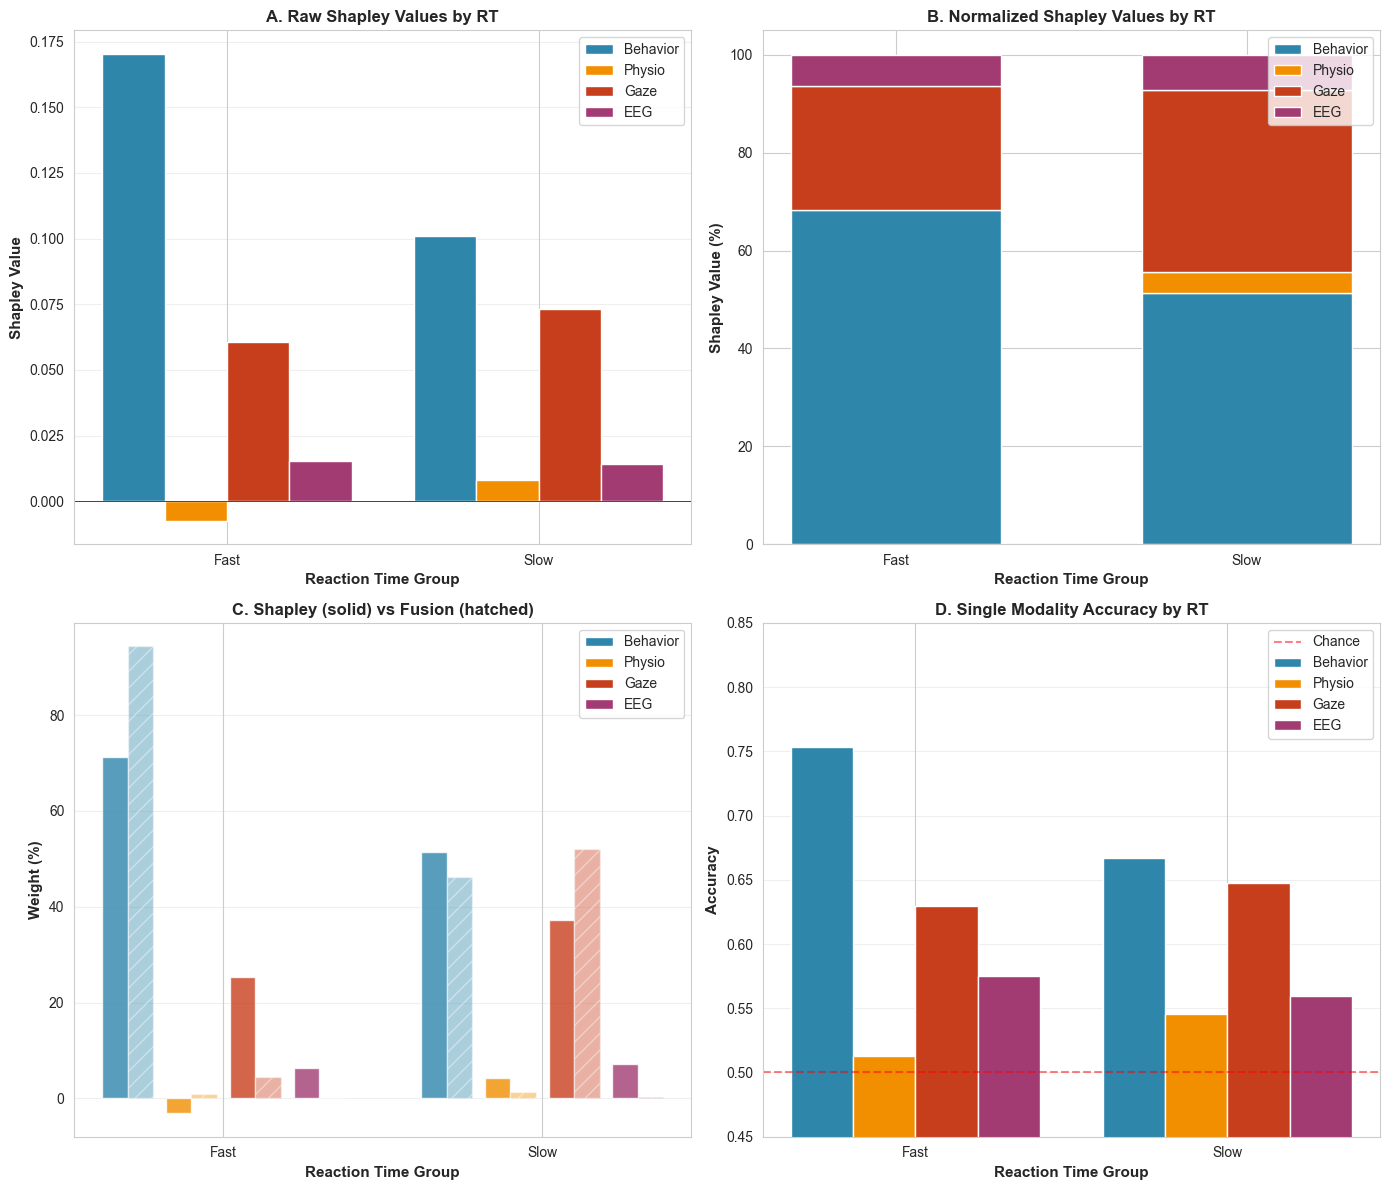

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = {'Behavior': '#2E86AB', 'Physio': '#F18F01', 'Gaze': '#C73E1D', 'EEG': '#A23B72'}

# 1. Raw Shapley values by RT
ax1 = axes[0, 0]
x = np.arange(2)
width = 0.2

for i, mod in enumerate(modality_names):
    vals = [rt_results[rt][mod] for rt in ['Fast', 'Slow']]
    ax1.bar(x + (i - 1.5) * width, vals, width, label=mod, color=colors[mod])

ax1.set_xticks(x)
ax1.set_xticklabels(['Fast', 'Slow'])
ax1.set_xlabel('Reaction Time Group', fontweight='bold')
ax1.set_ylabel('Shapley Value', fontweight='bold')
ax1.set_title('A. Raw Shapley Values by RT', fontweight='bold')
ax1.legend()
ax1.axhline(0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Normalized Shapley values (stacked bar)
ax2 = axes[0, 1]
bottom = np.zeros(2)

for mod in modality_names:
    vals = [comparison_df[comparison_df['rt_group'] == rt][f'{mod}_pct'].values[0] 
            for rt in ['Fast', 'Slow']]
    ax2.bar(x, vals, width=0.6, bottom=bottom, label=mod, color=colors[mod])
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(['Fast', 'Slow'])
ax2.set_xlabel('Reaction Time Group', fontweight='bold')
ax2.set_ylabel('Shapley Value (%)', fontweight='bold')
ax2.set_title('B. Normalized Shapley Values by RT', fontweight='bold')
ax2.legend(loc='upper right')
ax2.set_ylim([0, 105])

# 3. Shapley vs Fusion weights comparison
ax3 = axes[1, 0]
if fusion_comparison:
    bar_width = 0.15
    
    for i, mod in enumerate(modality_names):
        mod_data = fusion_df[fusion_df['modality'] == mod]
        x_pos = np.arange(2) + i * 0.2 - 0.3
        
        shapley_vals = [mod_data[mod_data['rt_group'] == rt]['shapley_pct'].values[0] 
                        for rt in ['Fast', 'Slow']]
        fusion_vals = [mod_data[mod_data['rt_group'] == rt]['fusion_pct'].values[0] 
                       for rt in ['Fast', 'Slow']]
        
        ax3.bar(x_pos - 0.04, shapley_vals, 0.08, color=colors[mod], alpha=0.8, label=f'{mod}' if i == 0 else '')
        ax3.bar(x_pos + 0.04, fusion_vals, 0.08, color=colors[mod], alpha=0.4, hatch='//')
    
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Fast', 'Slow'])
    ax3.set_xlabel('Reaction Time Group', fontweight='bold')
    ax3.set_ylabel('Weight (%)', fontweight='bold')
    ax3.set_title('C. Shapley (solid) vs Fusion (hatched)', fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add legend for modalities
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[mod], label=mod) for mod in modality_names]
    ax3.legend(handles=legend_elements, loc='upper right')
else:
    ax3.text(0.5, 0.5, 'Fusion weights not available', ha='center', va='center', transform=ax3.transAxes)

# 4. Single modality accuracies by RT
ax4 = axes[1, 1]
single_mod_accs = {}
for rt in ['Fast', 'Slow']:
    single_mod_accs[rt] = {}
    for mod in modality_names:
        single_mod_accs[rt][mod] = rt_coalitions[rt][frozenset([mod])]

x = np.arange(2)
for i, mod in enumerate(modality_names):
    vals = [single_mod_accs[rt][mod] for rt in ['Fast', 'Slow']]
    ax4.bar(x + (i - 1.5) * width, vals, width, label=mod, color=colors[mod])

ax4.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax4.set_xticks(x)
ax4.set_xticklabels(['Fast', 'Slow'])
ax4.set_xlabel('Reaction Time Group', fontweight='bold')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('D. Single Modality Accuracy by RT', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([0.45, 0.85])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shapley_by_rt.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Results

In [9]:
# Save main comparison
comparison_df.to_csv(OUTPUT_DIR / 'shapley_by_rt.csv', index=False)

# Save coalition values for each RT group
for rt in ['Fast', 'Slow']:
    coalition_df = pd.DataFrame([
        {'coalition': ', '.join(sorted(k)) if k else '(empty)', 
         'n_modalities': len(k),
         'accuracy': v}
        for k, v in rt_coalitions[rt].items()
    ]).sort_values(['n_modalities', 'accuracy'], ascending=[True, False])
    coalition_df.to_csv(OUTPUT_DIR / f'coalition_accuracies_{rt.lower()}_rt.csv', index=False)

# Save Shapley vs Fusion comparison
if fusion_comparison:
    fusion_df.to_csv(OUTPUT_DIR / 'shapley_vs_fusion_by_rt.csv', index=False)

print(f"\nResults saved to: {OUTPUT_DIR}/")


Results saved to: ../../data/results/main/shapley_analysis/


## 8. Summary

In [10]:
print("\n" + "="*70)
print("SUMMARY: SHAPLEY VALUES BY REACTION TIME")
print("="*70)

print("\nKey Question: Does the relative contribution of physiological/neural")
print("signals differ between fast (automatic) vs slow (deliberative) decisions?")

print("\nNormalized Shapley Values (%):")
print(f"{'Modality':<12} {'Fast':>10} {'Slow':>10} {'Change (S-F)':>12}")
print("-" * 46)

for mod in modality_names:
    fast = comparison_df[comparison_df['rt_group'] == 'Fast'][f'{mod}_pct'].values[0]
    slow = comparison_df[comparison_df['rt_group'] == 'Slow'][f'{mod}_pct'].values[0]
    change = slow - fast
    print(f"{mod:<12} {fast:>10.1f} {slow:>10.1f} {change:>+12.1f}")

print("\nSingle Modality Accuracy:")
print(f"{'Modality':<12} {'Fast':>10} {'Slow':>10}")
print("-" * 34)

for mod in modality_names:
    fast = single_mod_accs['Fast'][mod]
    slow = single_mod_accs['Slow'][mod]
    print(f"{mod:<12} {fast:>10.3f} {slow:>10.3f}")

print("\nInterpretation:")
print("- Fast trials: More automatic/intuitive decisions")
print("- Slow trials: More deliberative/effortful decisions")
print("- Changes in Shapley values indicate which modalities are more")
print("  informative for different types of decision-making processes.")


SUMMARY: SHAPLEY VALUES BY REACTION TIME

Key Question: Does the relative contribution of physiological/neural
signals differ between fast (automatic) vs slow (deliberative) decisions?

Normalized Shapley Values (%):
Modality           Fast       Slow Change (S-F)
----------------------------------------------
Behavior           71.3       51.4        -19.9
Physio             -3.1        4.2         +7.3
Gaze               25.4       37.1        +11.8
EEG                 6.4        7.3         +0.8

Single Modality Accuracy:
Modality           Fast       Slow
----------------------------------
Behavior          0.754      0.667
Physio            0.513      0.545
Gaze              0.629      0.647
EEG               0.575      0.559

Interpretation:
- Fast trials: More automatic/intuitive decisions
- Slow trials: More deliberative/effortful decisions
- Changes in Shapley values indicate which modalities are more
  informative for different types of decision-making processes.
